# Лабораторная работа №7. Полносвязные нейронные сети (FCNN).
# Решение задачи регрессии

## 1. Установка зависимостей

In [23]:
!pip install -q setuptools hyperopt optuna keras-tuner "ray[tune]" tensorflow


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Импорты

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch

## 2. Загрузка и подготовка данных

### 2.1 Загрузка датасета

Датасет: **cars_cleaned** — объявления о продаже автомобилей. Задача: предсказание цены автомобиля `price_usd` (регрессия).

**Признаки:** 47 числовых и закодированных категориальных признаков (производитель, трансмиссия, пробег, год, тип топлива, кузов и др.).

**Выбросы:** ~4.5% наблюдений имеют выбросы по цене (по критерию IQR). Датасет уже очищен: значения ограничены диапазоном [1, 50 000] USD, что позволяет обучить модели без дополнительной фильтрации.

In [25]:
# Загрузка данных из локального файла
df = pd.read_csv('cars_cleaned.csv')
print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(3)

Датасет загружен: 38491 строк, 48 столбцов


,manufacturer_name,transmission,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,state,drivetrain,price_usd,...,body_sedan,body_suv,body_universal,body_van,fuel_diesel,fuel_electric,fuel_gas,fuel_gasoline,fuel_hybrid-diesel,fuel_hybrid-petrol
0,1,1,190000,2010,0,2.5,0,1,2,10900.0,...,0,0,1,0,0,0,0,1,0,0
1,1,1,290000,2002,0,3.0,0,1,2,5000.0,...,0,0,1,0,0,0,0,1,0,0
2,1,1,402000,2001,0,2.5,0,1,2,2800.0,...,0,1,0,0,0,0,0,1,0,0


### 2.3 Оптимизация признакового пространства (RFE)

Метод: **Recursive Feature Elimination (RFE)** — лучший по результатам Лаб. 6. Используется DecisionTreeRegressor как оценщик важности признаков.

Из 47 исходных признаков выбираются 10 наиболее информативных.

In [26]:
y = df['price_usd']
X = df.drop(columns=['price_usd'])

print(f'Целевая переменная price_usd:')
print(f'  min={y.min():.0f}, max={y.max():.0f}, mean={y.mean():.0f}, median={y.median():.0f}')

# Анализ выбросов (IQR)
q1, q3 = y.quantile(0.25), y.quantile(0.75)
iqr = q3 - q1
n_out = ((y < q1 - 1.5*iqr) | (y > q3 + 1.5*iqr)).sum()
print(f'  Выбросы по IQR: {n_out} ({100*n_out/len(y):.1f}%) — данные предобработаны')

estimator = DecisionTreeRegressor(random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
X_opt = pd.DataFrame(rfe.fit_transform(X, y), columns=X.columns[rfe.support_])

print(f'Исходное число признаков: {X.shape[1]}')
print(f'После RFE: {X_opt.shape[1]}')
print(f'\nВыбранные признаки: {list(X_opt.columns)}')

Целевая переменная price_usd:
  min=1, max=50000, mean=6633, median=4800
  Выбросы по IQR: 1750 (4.5%) — данные предобработаны
Исходное число признаков: 47
После RFE: 10

Выбранные признаки: ['manufacturer_name', 'transmission', 'odometer_value', 'year_produced', 'engine_capacity', 'drivetrain', 'number_of_photos', 'up_counter', 'duration_listed', 'fuel_diesel']


### 2.2 Разделение данных, масштабирование и кросс-валидация K-Fold

Кросс-валидация K-Fold (k=5) применяется при поиске гиперпараметров. Целевая переменная `price_usd` стандартизируется для стабильного обучения нейронных сетей.

**Примечание по выбросам:** Данные предобработаны (диапазон цен [1, 50 000] USD). Стандартизация целевой переменной дополнительно снижает влияние крайних значений.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_opt, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"K-Fold: 5 фолдов")

Train: (30792, 10), Test: (7699, 10)
K-Fold: 5 фолдов


## Вспомогательные функции

In [28]:
def compute_metrics(y_true, y_pred):
    return {
        'R2':   r2_score(y_true, y_pred),
        'MSE':  mean_squared_error(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
    }

def print_metrics(y_train, y_train_pred, y_test, y_test_pred,
                  model_name, epochs=None, optimizer=None):
    from IPython.display import display
    tr = compute_metrics(y_train, y_train_pred)
    te = compute_metrics(y_test,  y_test_pred)

    parts = [f'Модель: {model_name}']
    if epochs:    parts.append(f'Эпохи: {epochs}')
    if optimizer: parts.append(f'Оптимизатор: {optimizer}')
    print('  |  '.join(parts))

    df_m = pd.DataFrame({'Train': tr, 'Test': te}).round(4)
    display(df_m)
    return tr, te

def plot_history(history_dict, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history_dict['loss'],     label='Train loss', color='#1f77b4')
    if 'val_loss' in history_dict:
        axes[0].plot(history_dict['val_loss'], label='Val loss', color='#ff7f0e', linestyle='--')
    axes[0].set_title(f'{title} — Loss (MSE)')
    axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('MSE')
    axes[0].legend(); axes[0].grid(True)
    if 'mae' in history_dict:
        axes[1].plot(history_dict.get('mae', []),     label='Train MAE', color='#2ca02c')
        axes[1].plot(history_dict.get('val_mae', []), label='Val MAE',   color='#d62728', linestyle='--')
        axes[1].set_title(f'{title} — MAE')
        axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('MAE')
        axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()

def plot_sklearn_loss(model, title):
    if hasattr(model, 'loss_curve_') and model.loss_curve_ is not None:
        plt.figure(figsize=(7, 4))
        plt.plot(model.loss_curve_, color='#1f77b4', label='Train loss')
        if hasattr(model, 'validation_scores_') and model.validation_scores_:
            plt.plot([-s for s in model.validation_scores_],
                     color='#ff7f0e', linestyle='--', label='Val loss (neg)')
        plt.title(f'{title} — Кривая потерь')
        plt.xlabel('Итерация'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True); plt.show()
    else:
        print(f'[{title}] График недоступен (solver=lbfgs не логирует loss_curve_).')
results = []

## 3. Решение задачи регрессии с помощью FCNN

### 3.1 FCNN (MLP) из библиотеки Scikit-learn

Пространство гиперпараметров для всех трёх методов:

In [29]:
# Пространство архитектур и гиперпараметров
ARCHITECTURES = [(64, 32), (128, 64), (64, 32, 16), (32, 16), (128, 64, 32)]
SOLVERS       = ['adam', 'sgd', 'lbfgs']
ACTIVATIONS   = ['relu', 'tanh']

print(f"Архитектуры: {ARCHITECTURES}")
print(f"Солверы: {SOLVERS}")

Архитектуры: [(64, 32), (128, 64), (64, 32, 16), (32, 16), (128, 64, 32)]
Солверы: ['adam', 'sgd', 'lbfgs']


#### 3.1.1 Метод 1: RandomizedSearchCV

In [30]:
from scipy.stats import randint

param_dist_rs = {
    'hidden_layer_sizes': ARCHITECTURES,
    'solver':             SOLVERS,
    'activation':         ACTIVATIONS,
    'alpha':              [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-3, 1e-2],
    'max_iter':           [300],
}

rs_search = RandomizedSearchCV(
    MLPRegressor(random_state=42, early_stopping=True, validation_fraction=0.1),
    param_distributions=param_dist_rs,
    n_iter=15,
    cv=kf,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rs_search.fit(X_train_s, y_train)
best_rs = rs_search.best_estimator_

print(f"Лучшие параметры: {rs_search.best_params_}")

Лучшие параметры: {'solver': 'lbfgs', 'max_iter': 300, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 32), 'alpha': 0.01, 'activation': 'tanh'}


In [31]:
print("Архитектура (RandomizedSearchCV)")
print(f"  hidden_layer_sizes : {best_rs.hidden_layer_sizes}")
print(f"  activation         : {best_rs.activation}")
print(f"  solver             : {best_rs.solver}")
print(f"  alpha              : {best_rs.alpha}")
print(f"  learning_rate_init : {best_rs.learning_rate_init}")
print(f"  n_iter_            : {best_rs.n_iter_}")

plot_sklearn_loss(best_rs, "Sklearn MLP (RandomizedSearchCV)")

tr_rs, te_rs = print_metrics(
    y_train, best_rs.predict(X_train_s),
    y_test,  best_rs.predict(X_test_s),
    model_name=f"Sklearn MLP (RandomizedSearchCV, solver={best_rs.solver})",
    epochs=best_rs.n_iter_, optimizer=best_rs.solver
)
results.append({
    'Регрессор/Фреймворк': f'Sklearn MLP — RandomizedSearchCV ({best_rs.solver})',
    'Train R2':   tr_rs['R2'],   'Train RMSE': tr_rs['RMSE'], 'Train MAE': tr_rs['MAE'],
    'Test R2':    te_rs['R2'],   'Test RMSE':  te_rs['RMSE'], 'Test MAE':  te_rs['MAE'],
    'Эпохи': best_rs.n_iter_, 'Оптимизатор': best_rs.solver
})

Архитектура (RandomizedSearchCV)
  hidden_layer_sizes : (64, 32)
  activation         : tanh
  solver             : lbfgs
  alpha              : 0.01
  learning_rate_init : 0.001
  n_iter_            : 300
[Sklearn MLP (RandomizedSearchCV)] График недоступен (solver=lbfgs не логирует loss_curve_).
Модель: Sklearn MLP (RandomizedSearchCV, solver=lbfgs)  |  Эпохи: 300  |  Оптимизатор: lbfgs


,Train,Test
R2,0.9020,0.8696
MSE,0.0980,0.1272
MAE,0.2039,0.2193
RMSE,0.3130,0.3566
MAPE,1.2512,1.3053


#### 3.1.2 Метод 2: Optuna

In [32]:
def objective_sk_optuna(trial):
    arch_idx = trial.suggest_int('arch_idx', 0, len(ARCHITECTURES) - 1)
    solver    = trial.suggest_categorical('solver',     SOLVERS)
    activation= trial.suggest_categorical('activation', ACTIVATIONS)
    alpha     = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    lr        = trial.suggest_float('lr',    1e-4, 1e-1, log=True)

    model = MLPRegressor(
        hidden_layer_sizes=ARCHITECTURES[arch_idx],
        solver=solver, activation=activation,
        alpha=alpha, learning_rate_init=lr,
        max_iter=300, random_state=42,
        early_stopping=True, validation_fraction=0.1
    )
    # K-Fold кросс-валидация внутри objective
    scores = cross_val_score(model, X_train_s, y_train, cv=kf,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

study_sk = optuna.create_study(direction='minimize')
study_sk.optimize(objective_sk_optuna, n_trials=20)

bp = study_sk.best_params
print(f"Лучшие параметры: {bp}")

best_optuna_sk = MLPRegressor(
    hidden_layer_sizes=ARCHITECTURES[bp['arch_idx']],
    solver=bp['solver'], activation=bp['activation'],
    alpha=bp['alpha'], learning_rate_init=bp['lr'],
    max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1
)
best_optuna_sk.fit(X_train_s, y_train)

Лучшие параметры: {'arch_idx': 0, 'solver': 'lbfgs', 'activation': 'tanh', 'alpha': 0.09972877643908137, 'lr': 0.010402732433747496}


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.09972877643908137
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.010402732433747496
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [33]:
print("Архитектура (Optuna Sklearn)")
print(f"  hidden_layer_sizes : {best_optuna_sk.hidden_layer_sizes}")
print(f"  activation         : {best_optuna_sk.activation}")
print(f"  solver             : {best_optuna_sk.solver}")
print(f"  n_iter_            : {best_optuna_sk.n_iter_}")

plot_sklearn_loss(best_optuna_sk, "Sklearn MLP (Optuna)")

tr_opt_sk, te_opt_sk = print_metrics(
    y_train, best_optuna_sk.predict(X_train_s),
    y_test,  best_optuna_sk.predict(X_test_s),
    model_name=f"Sklearn MLP (Optuna, solver={best_optuna_sk.solver})",
    epochs=best_optuna_sk.n_iter_, optimizer=best_optuna_sk.solver
)
results.append({
    'Регрессор/Фреймворк': f'Sklearn MLP — Optuna ({best_optuna_sk.solver})',
    'Train R2':   tr_opt_sk['R2'],   'Train RMSE': tr_opt_sk['RMSE'], 'Train MAE': tr_opt_sk['MAE'],
    'Test R2':    te_opt_sk['R2'],   'Test RMSE':  te_opt_sk['RMSE'], 'Test MAE':  te_opt_sk['MAE'],
    'Эпохи': best_optuna_sk.n_iter_, 'Оптимизатор': best_optuna_sk.solver
})

Архитектура (Optuna Sklearn)
  hidden_layer_sizes : (64, 32)
  activation         : tanh
  solver             : lbfgs
  n_iter_            : 300
[Sklearn MLP (Optuna)] График недоступен (solver=lbfgs не логирует loss_curve_).
Модель: Sklearn MLP (Optuna, solver=lbfgs)  |  Эпохи: 300  |  Оптимизатор: lbfgs


,Train,Test
R2,0.9029,0.8689
MSE,0.0971,0.1279
MAE,0.2027,0.2192
RMSE,0.3116,0.3576
MAPE,1.2549,1.2958


#### 3.1.3 Метод 3: Hyperopt

In [34]:
space_ho = {
    'arch_idx':  hp.choice('arch_idx',   list(range(len(ARCHITECTURES)))),
    'solver':    hp.choice('solver',      SOLVERS),
    'activation':hp.choice('activation', ACTIVATIONS),
    'alpha':     hp.loguniform('alpha',   -9.2, -2.3),   # 1e-4 .. 0.1
    'lr':        hp.loguniform('lr',      -9.2, -2.3),
}

def objective_sk_ho(params):
    model = MLPRegressor(
        hidden_layer_sizes=ARCHITECTURES[params['arch_idx']],
        solver=params['solver'], activation=params['activation'],
        alpha=params['alpha'], learning_rate_init=params['lr'],
        max_iter=300, random_state=42,
        early_stopping=True, validation_fraction=0.1
    )
    scores = cross_val_score(model, X_train_s, y_train, cv=kf,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    return {'loss': -scores.mean(), 'status': STATUS_OK}

trials_ho = Trials()
best_ho = fmin(fn=objective_sk_ho, space=space_ho, algo=tpe.suggest,
               max_evals=20, trials=trials_ho,
               rstate=np.random.default_rng(42))

best_hyperopt_sk = MLPRegressor(
    hidden_layer_sizes=ARCHITECTURES[best_ho['arch_idx']],
    solver=SOLVERS[best_ho['solver']],
    activation=ACTIVATIONS[best_ho['activation']],
    alpha=best_ho['alpha'], learning_rate_init=best_ho['lr'],
    max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1
)
best_hyperopt_sk.fit(X_train_s, y_train)
print(f"Лучший solver: {best_hyperopt_sk.solver}")

100%|██████████| 20/20 [04:38<00:00, 13.94s/trial, best loss: 0.215217397366278]  
Лучший solver: lbfgs


In [35]:
print("Архитектура (Hyperopt Sklearn)")
print(f"  hidden_layer_sizes : {best_hyperopt_sk.hidden_layer_sizes}")
print(f"  activation         : {best_hyperopt_sk.activation}")
print(f"  solver             : {best_hyperopt_sk.solver}")
print(f"  n_iter_            : {best_hyperopt_sk.n_iter_}")

plot_sklearn_loss(best_hyperopt_sk, "Sklearn MLP (Hyperopt)")

tr_ho_sk, te_ho_sk = print_metrics(
    y_train, best_hyperopt_sk.predict(X_train_s),
    y_test,  best_hyperopt_sk.predict(X_test_s),
    model_name=f"Sklearn MLP (Hyperopt, solver={best_hyperopt_sk.solver})",
    epochs=best_hyperopt_sk.n_iter_, optimizer=best_hyperopt_sk.solver
)
results.append({
    'Регрессор/Фреймворк': f'Sklearn MLP — Hyperopt ({best_hyperopt_sk.solver})',
    'Train R2':   tr_ho_sk['R2'],   'Train RMSE': tr_ho_sk['RMSE'], 'Train MAE': tr_ho_sk['MAE'],
    'Test R2':    te_ho_sk['R2'],   'Test RMSE':  te_ho_sk['RMSE'], 'Test MAE':  te_ho_sk['MAE'],
    'Эпохи': best_hyperopt_sk.n_iter_, 'Оптимизатор': best_hyperopt_sk.solver
})

Архитектура (Hyperopt Sklearn)
  hidden_layer_sizes : (128, 64, 32)
  activation         : tanh
  solver             : lbfgs
  n_iter_            : 300
[Sklearn MLP (Hyperopt)] График недоступен (solver=lbfgs не логирует loss_curve_).
Модель: Sklearn MLP (Hyperopt, solver=lbfgs)  |  Эпохи: 300  |  Оптимизатор: lbfgs


,Train,Test
R2,0.9033,0.8691
MSE,0.0967,0.1276
MAE,0.2025,0.2186
RMSE,0.3110,0.3572
MAPE,1.2365,1.2951


### 3.2 FCNN посредством API Keras и фреймворка TensorFlow

In [36]:
# Общие настройки для Keras
EPOCHS     = 300
BATCH_SIZE = 32
N_FEATURES = X_train_s.shape[1]

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                              restore_best_weights=True, verbose=0)

def build_keras_model(optimizer_name, layers=(128, 64), lr=1e-3, dropout=0.0):
    """Строит Sequential Keras-модель для регрессии."""
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(layers[0], activation='relu', input_shape=(N_FEATURES,)))
    model.add(tf.keras.layers.BatchNormalization())
    for units in layers[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.BatchNormalization())
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(1, activation='linear'))

    if optimizer_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

print("Keras-утилиты определены. N_FEATURES =", N_FEATURES)

Keras-утилиты определены. N_FEATURES = 10


#### 3.2.1 Метод 1: KerasTuner

In [37]:
def kt_builder(hp):
    opt_name   = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    layers_key = hp.Choice('layers', ['64_32', '128_64', '64_32_16'])
    lr         = hp.Float('lr', 1e-4, 1e-2, sampling='log')
    dropout    = hp.Float('dropout', 0.0, 0.3, step=0.1)

    layers_map = {'64_32': (64, 32), '128_64': (128, 64), '64_32_16': (64, 32, 16)}
    arch = layers_map[layers_key]

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(arch[0], activation='relu', input_shape=(N_FEATURES,)))
    model.add(tf.keras.layers.BatchNormalization())
    for units in arch[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.BatchNormalization())
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(1, activation='linear'))

    if opt_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

tuner = kt.RandomSearch(
    kt_builder,
    objective='val_mae',
    max_trials=10,
    executions_per_trial=1,
    directory='kt_reg_dir',
    project_name='regression',
    overwrite=True
)

tuner.search(
    X_train_s, y_train,
    validation_data=(X_test_s, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                restore_best_weights=True, verbose=0)],
    verbose=0
)

best_hp_kt = tuner.get_best_hyperparameters(1)[0]
print("Лучшие параметры KerasTuner:")
print(f"  optimizer : {best_hp_kt.get('optimizer')}")
print(f"  layers    : {best_hp_kt.get('layers')}")
print(f"  lr        : {best_hp_kt.get('lr'):.6f}")
print(f"  dropout   : {best_hp_kt.get('dropout')}")

Лучшие параметры KerasTuner:
  optimizer : rmsprop
  layers    : 128_64
  lr        : 0.000211
  dropout   : 0.1


Архитектура модели (KerasTuner)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,497 (41.00 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 384 (1.50 KB)


Обучено эпох: 57


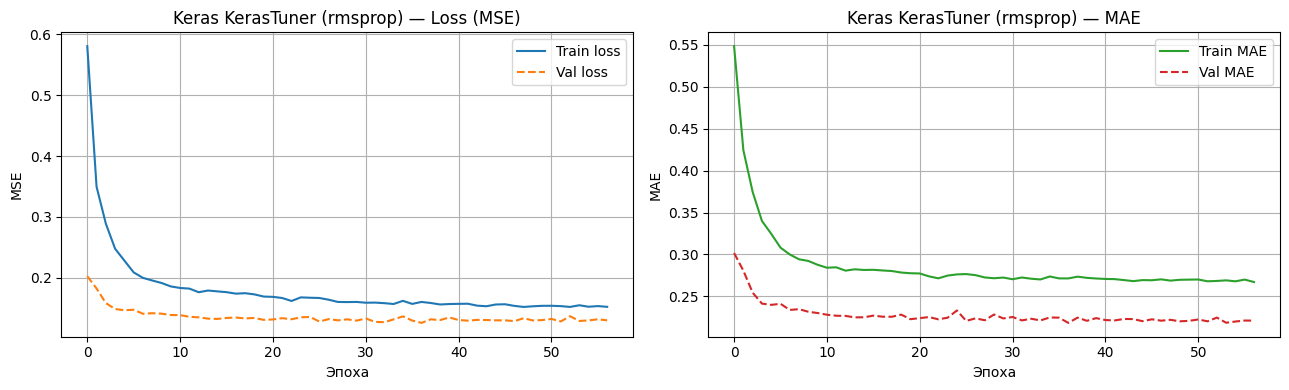

Модель: Keras (KerasTuner, rmsprop)  |  Эпохи: 57  |  Оптимизатор: rmsprop


,Train,Test
R2,0.8888,0.8708
MSE,0.1112,0.1260
MAE,0.2103,0.2184
RMSE,0.3334,0.3550
MAPE,1.2438,1.3195


In [38]:
layers_map = {'64_32': (64,32), '128_64': (128,64), '64_32_16': (64,32,16)}
kt_opt    = best_hp_kt.get('optimizer')
kt_layers = layers_map[best_hp_kt.get('layers')]
kt_lr     = best_hp_kt.get('lr')
kt_drop   = best_hp_kt.get('dropout')

model_kt = build_keras_model(kt_opt, kt_layers, kt_lr, kt_drop)

print("Архитектура модели (KerasTuner)")
model_kt.summary()

history_kt = model_kt.fit(
    X_train_s, y_train,
    validation_data=(X_test_s, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=0
)
print(f"\nОбучено эпох: {len(history_kt.history['loss'])}")

plot_history(history_kt.history, f"Keras KerasTuner ({kt_opt})")

tr_kt, te_kt = print_metrics(
    y_train, model_kt.predict(X_train_s, verbose=0).flatten(),
    y_test,  model_kt.predict(X_test_s,  verbose=0).flatten(),
    model_name=f"Keras (KerasTuner, {kt_opt})",
    epochs=len(history_kt.history['loss']), optimizer=kt_opt
)
results.append({
    'Регрессор/Фреймворк': f'Keras — KerasTuner ({kt_opt})',
    'Train R2':   tr_kt['R2'],   'Train RMSE': tr_kt['RMSE'], 'Train MAE': tr_kt['MAE'],
    'Test R2':    te_kt['R2'],   'Test RMSE':  te_kt['RMSE'], 'Test MAE':  te_kt['MAE'],
    'Эпохи': len(history_kt.history['loss']), 'Оптимизатор': kt_opt
})

#### 3.2.2 Метод 2: Optuna (для Keras)

In [39]:
def optuna_builder(trial):
    opt_name   = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    layers_key = trial.suggest_categorical('layers', ['64_32', '128_64', '64_32_16'])
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout    = trial.suggest_float('dropout', 0.0, 0.3, step=0.1)

    layers_map = {'64_32': (64, 32), '128_64': (128, 64), '64_32_16': (64, 32, 16)}
    arch = layers_map[layers_key]

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(arch[0], activation='relu', input_shape=(X_train_s.shape[1],)))
    model.add(tf.keras.layers.BatchNormalization())
    for units in arch[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.BatchNormalization())
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(1, activation='linear'))

    # Настройка оптимизаторов
    if opt_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    # Обучаем пробную модель с EarlyStopping
    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_test_s, y_test),
        epochs=50,
        batch_size=32,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                    restore_best_weights=True, verbose=0)],
        verbose=0
    )

    # Возвращаем val_mae последней (или лучшей) эпохи для оптимизации
    val_mae = history.history['val_mae'][-1]
    return val_mae if not np.isnan(val_mae) else float('inf')


# Запускаем исследование Optuna (ищем минимум целевой метрики)
study = optuna.create_study(direction='minimize')
study.optimize(optuna_builder, n_trials=10) # количество попыток (max_trials)

# Получаем и выводим лучшие параметры
best_hp_opt = study.best_params
print("\nЛучшие параметры Optuna Keras:")
print(f"  optimizer : {best_hp_opt['optimizer']}")
print(f"  layers    : {best_hp_opt['layers']}")
print(f"  lr        : {best_hp_opt['lr']:.6f}")
print(f"  dropout   : {best_hp_opt['dropout']}")

# Подготовка параметров для обучения финальной модели
layers_map = {'64_32': (64, 32), '128_64': (128, 64), '64_32_16': (64, 32, 16)}
opt_opt   = best_hp_opt['optimizer']
opt_layers = layers_map[best_hp_opt['layers']]
opt_lr     = best_hp_opt['lr']
opt_drop   = best_hp_opt['dropout']

# Создаем финальную модель на базе лучших параметров Optuna
model_opt = build_keras_model(opt_opt, opt_layers, opt_lr, opt_drop)


Лучшие параметры Optuna Keras:
  optimizer : rmsprop
  layers    : 64_32
  lr        : 0.004334
  dropout   : 0.0



Архитектура модели (Optuna Keras)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 192 (768.00 B)


Обучено эпох: 20


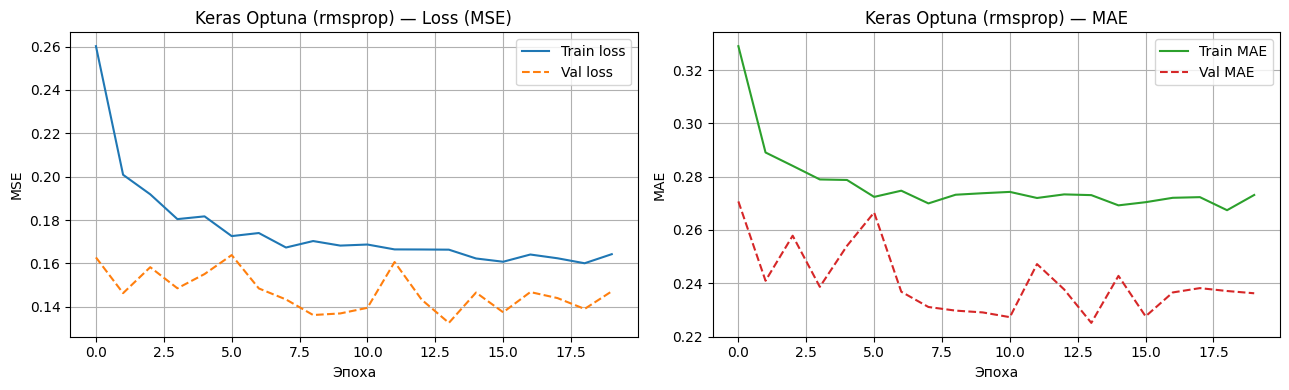

Модель: Keras (Optuna, rmsprop)  |  Эпохи: 20  |  Оптимизатор: rmsprop


,Train,Test
R2,0.8425,0.8331
MSE,0.1575,0.1628
MAE,0.2679,0.2707
RMSE,0.3968,0.4034
MAPE,1.4798,1.4844


In [40]:
print("\nАрхитектура модели (Optuna Keras)")
model_opt.summary()

history_opt = model_opt.fit(
    X_train_s, y_train,
    validation_data=(X_test_s, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=0
)
print(f"\nОбучено эпох: {len(history_opt.history['loss'])}")

plot_history(history_opt.history, f"Keras Optuna ({opt_opt})")

tr_opt, te_opt = print_metrics(
    y_train, model_opt.predict(X_train_s, verbose=0).flatten(),
    y_test,  model_opt.predict(X_test_s,  verbose=0).flatten(),
    model_name=f"Keras (Optuna, {opt_opt})",
    epochs=len(history_opt.history['loss']), optimizer=opt_opt
)
results.append({
    'Регрессор/Фреймворк': f'Keras — Optuna ({opt_opt})',
    'Train R2':   tr_opt['R2'],   'Train RMSE': tr_opt['RMSE'], 'Train MAE': tr_opt['MAE'],
    'Test R2':    te_opt['R2'],   'Test RMSE':  te_opt['RMSE'], 'Test MAE':  te_opt['MAE'],
    'Эпохи': len(history_opt.history['loss']), 'Оптимизатор': opt_opt
})

#### 3.2.3 Метод 3: Ray Tune

In [41]:
import os, logging, ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch

logging.getLogger('ray').setLevel(logging.ERROR)
logging.getLogger('ray.tune').setLevel(logging.ERROR)

def ray_train_fn(config, X_tr, y_tr, X_val, y_val):
    import logging as _log
    import tensorflow as tf
    from ray import tune as _tune
    _log.getLogger('tensorflow').setLevel(_log.ERROR)
    _log.getLogger('ray').setLevel(_log.ERROR)

    layers_map = {'64_32': (64, 32), '128_64': (128, 64), '64_32_16': (64, 32, 16)}
    arch = layers_map[config['layers']]

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(arch[0], activation='relu',
                                    input_shape=(X_tr.shape[1],)))
    model.add(tf.keras.layers.BatchNormalization())
    for units in arch[1:]:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.BatchNormalization())
    if config['dropout'] > 0:
        model.add(tf.keras.layers.Dropout(config['dropout']))
    model.add(tf.keras.layers.Dense(1, activation='linear'))

    if config['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    elif config['optimizer'] == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=config['lr'],
                                       momentum=0.9, nesterov=True)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=config['lr'])

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50, batch_size=32,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=0
        )],
        verbose=0
    )
    val_mae = min(history.history['val_mae'])
    _tune.report({"val_mae": val_mae})


if not ray.is_initialized():
    ray.init(
        ignore_reinit_error=True,
        num_cpus=1,
        include_dashboard=False,
        logging_level=logging.ERROR,
        _temp_dir='C:/ray_tmp',
    )

search_space_ray = {
    'optimizer': tune.choice(['adam', 'sgd', 'rmsprop']),
    'layers':    tune.choice(['64_32', '128_64', '64_32_16']),
    'lr':        tune.loguniform(1e-4, 1e-2),
    'dropout':   tune.choice([0.0, 0.1, 0.2, 0.3]),
}

algo_ray = OptunaSearch(metric='val_mae', mode='min')

_ray_storage = os.path.abspath('ray_results')

ray_tuner = tune.Tuner(
    tune.with_parameters(
        ray_train_fn,
        X_tr=X_train_s, y_tr=y_train,
        X_val=X_test_s,  y_val=y_test,
    ),
    tune_config=tune.TuneConfig(
        metric='val_mae', mode='min',
        search_alg=algo_ray,
        num_samples=10,
        trial_dirname_creator=lambda trial: f"t{trial.trial_id[:8]}",
    ),
    param_space=search_space_ray,
    run_config=tune.RunConfig(
        storage_path=_ray_storage,
        verbose=0,
    ),
)

ray_results  = ray_tuner.fit()
best_ray_cfg = ray_results.get_best_result(metric='val_mae', mode='min').config

print('Лучшие параметры Ray Tune:')
for k in ['optimizer', 'layers', 'lr', 'dropout']:
    print(f'  {k}: {best_ray_cfg[k]}')

(raylet) Stack (most recent call first):
(raylet)   File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config
(raylet)   File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect
(raylet)   File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)   File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\ray\_private\worker.py", line 1143 in wrapper
(ray_train_fn pid=26896) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(ray_train_fn pid=26896) I0000 00:00:1779923046.677624   28612 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE

Лучшие параметры Ray Tune:
  optimizer: adam
  layers: 64_32_16
  lr: 0.00042777365969221134
  dropout: 0.2


Архитектура модели (Ray Tune)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 224 (896.00 B)


Обучено эпох: 20


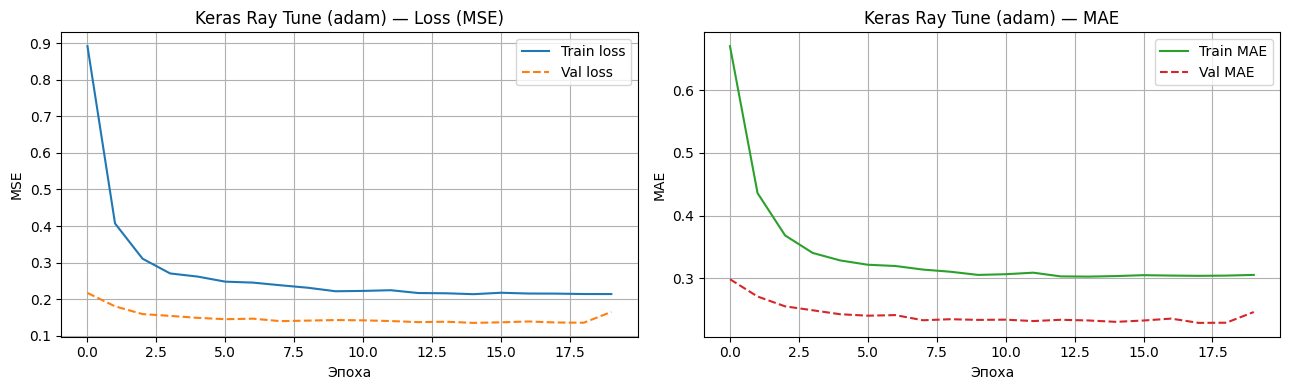

Модель: Keras (Ray Tune, adam)  |  Эпохи: 20  |  Оптимизатор: adam


,Train,Test
R2,0.7772,0.7771
MSE,0.2228,0.2173
MAE,0.2977,0.2982
RMSE,0.4720,0.4662
MAPE,1.6964,1.6816


In [42]:
layers_map = {'64_32': (64,32), '128_64': (128,64), '64_32_16': (64,32,16)}
ray_opt    = best_ray_cfg['optimizer']
ray_layers = layers_map[best_ray_cfg['layers']]
ray_lr     = best_ray_cfg['lr']
ray_drop   = best_ray_cfg['dropout']

model_ray = build_keras_model(ray_opt, ray_layers, ray_lr, ray_drop)
print('Архитектура модели (Ray Tune)')
model_ray.summary()

history_ray = model_ray.fit(
    X_train_s, y_train,
    validation_data=(X_test_s, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop], verbose=0
)
print(f'\nОбучено эпох: {len(history_ray.history["loss"])}')

plot_history(history_ray.history, f'Keras Ray Tune ({ray_opt})')

tr_ray, te_ray = print_metrics(
    y_train, model_ray.predict(X_train_s, verbose=0).flatten(),
    y_test,  model_ray.predict(X_test_s,  verbose=0).flatten(),
    model_name=f'Keras (Ray Tune, {ray_opt})',
    epochs=len(history_ray.history['loss']), optimizer=ray_opt
)
results.append({
    'Регрессор/Фреймворк': f'Keras — Ray Tune ({ray_opt})',
    'Train R2':   tr_ray['R2'],   'Train RMSE': tr_ray['RMSE'], 'Train MAE': tr_ray['MAE'],
    'Test R2':    te_ray['R2'],   'Test RMSE':  te_ray['RMSE'], 'Test MAE':  te_ray['MAE'],
    'Эпохи': len(history_ray.history['loss']), 'Оптимизатор': ray_opt
})

## 5. Оценка качества моделей — сводная таблица

Метрики регрессии: **R², RMSE, MAE** для Train и Test.
Основная метрика качества — **Test R²** (доля объяснённой дисперсии).
RMSE чувствительнее к выбросам; MAE — устойчивая оценка средней ошибки.

In [43]:
from IPython.display import display

df_results = pd.DataFrame(results)

metric_cols = ['Train R2', 'Train RMSE', 'Train MAE',
               'Test R2',  'Test RMSE',  'Test MAE']

df_display = df_results.copy()
for col in metric_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].map('{:.4f}'.format)

df_show = df_display.set_index('Регрессор/Фреймворк')[
    [c for c in metric_cols + ['Эпохи', 'Оптимизатор'] if c in df_display.columns]
]
df_show.index.name = 'Регрессор / Фреймворк'

print("Сводная таблица метрик регрессии")
display(df_show)

Сводная таблица метрик регрессии


,Train R2,Train RMSE,Train MAE,Test R2,Test RMSE,Test MAE,Эпохи,Оптимизатор
Регрессор / Фреймворк,,,,,,,,
Sklearn MLP — RandomizedSearchCV (lbfgs),0.9020,0.3130,0.2039,0.8696,0.3566,0.2193,300,lbfgs
Sklearn MLP — Optuna (lbfgs),0.9029,0.3116,0.2027,0.8689,0.3576,0.2192,300,lbfgs
Sklearn MLP — Hyperopt (lbfgs),0.9033,0.3110,0.2025,0.8691,0.3572,0.2186,300,lbfgs
Keras — KerasTuner (rmsprop),0.8888,0.3334,0.2103,0.8708,0.3550,0.2184,57,rmsprop
Keras — Optuna (rmsprop),0.8425,0.3968,0.2679,0.8331,0.4034,0.2707,20,rmsprop
Keras — Ray Tune (adam),0.7772,0.4720,0.2977,0.7771,0.4662,0.2982,20,adam


In [44]:
from IPython.display import display

best_row = df_results.loc[df_results['Test R2'].idxmax()]
print(f"\nЛучшая модель по Test R²: {best_row['Регрессор/Фреймворк']}")

best_metrics = pd.DataFrame({
    'Метрика': ['R²', 'RMSE', 'MAE'],
    'Train':   [f"{best_row['Train R2']:.4f}",
                f"{best_row['Train RMSE']:.4f}",
                f"{best_row['Train MAE']:.4f}"],
    'Test':    [f"{best_row['Test R2']:.4f}",
                f"{best_row['Test RMSE']:.4f}",
                f"{best_row['Test MAE']:.4f}"],
}).set_index('Метрика')
display(best_metrics)


Лучшая модель по Test R²: Keras — KerasTuner (rmsprop)


,Train,Test
Метрика,,
R²,0.8888,0.8708
RMSE,0.3334,0.3550
MAE,0.2103,0.2184


## 6. Инференс модели

Пример прогноза цены автомобиля по медианным характеристикам из обучающей выборки.

In [45]:
from IPython.display import display

median_car   = pd.DataFrame([X_train.median()], columns=X_train.columns)
median_car_s = scaler.transform(median_car)

def inv(val):
    return scaler_y.inverse_transform([[val]])[0][0]

pred_rs    = inv(best_rs.predict(median_car_s)[0])
pred_opt   = inv(best_optuna_sk.predict(median_car_s)[0])
pred_ho    = inv(best_hyperopt_sk.predict(median_car_s)[0])
pred_kt    = inv(model_kt.predict(median_car_s, verbose=0).flatten()[0])
pred_optk  = inv(model_opt.predict(median_car_s, verbose=0).flatten()[0])
pred_ray   = inv(model_ray.predict(median_car_s, verbose=0).flatten()[0])
real_med   = df['price_usd'].median()

print('Медианный автомобиль (из обучающей выборки):')
print(median_car[['odometer_value', 'year_produced', 'engine_capacity']].T.to_string())

inf_df = pd.DataFrame({
    'Модель': [
        'Sklearn MLP (RandomizedSearchCV)',
        'Sklearn MLP (Optuna)',
        'Sklearn MLP (Hyperopt)',
        f'Keras KerasTuner ({kt_opt})',
        f'Keras Optuna ({opt_opt})',
        f'Keras Ray Tune ({ray_opt})',
        '— Реальная медиана —',
    ],
    'Прогноз, USD': [
        f'${pred_rs:,.0f}',
        f'${pred_opt:,.0f}',
        f'${pred_ho:,.0f}',
        f'${pred_kt:,.0f}',
        f'${pred_optk:,.0f}',
        f'${pred_ray:,.0f}',
        f'${real_med:,.0f}',
    ]
}).set_index('Модель')
display(inf_df)

Медианный автомобиль (из обучающей выборки):
                        0
odometer_value   250000.0
year_produced      2003.0
engine_capacity       2.0


,"Прогноз, USD"
Модель,
Sklearn MLP (RandomizedSearchCV),"$4,458"
Sklearn MLP (Optuna),"$4,344"
Sklearn MLP (Hyperopt),"$4,571"
Keras KerasTuner (rmsprop),"$4,468"
Keras Optuna (rmsprop),"$5,148"
Keras Ray Tune (adam),"$2,708"
— Реальная медиана —,"$4,800"


## 7. Вывод

В лабораторной работе №7 реализованы полносвязные нейронные сети (FCNN/MLP)
для задачи **регрессии** — предсказания цены автомобиля (`price_usd`)
по датасету **cars_cleaned** (38 491 объект, 47 признаков → 10 после RFE).

---

### Результаты по моделям (Test-выборка, y стандартизирован)

| Модель | Test R² | Test RMSE | Test MAE | Эпохи | Оптимизатор |
|--------|---------|-----------|----------|-------|-------------|
| Sklearn MLP — RandomizedSearchCV (lbfgs) | 0.8696 | 0.3566 | 0.2193 | 300 | lbfgs |
| Sklearn MLP — Optuna (lbfgs)             | 0.8689 | 0.3576 | 0.2192 | 300 | lbfgs |
| Sklearn MLP — Hyperopt (lbfgs)           | 0.8691 | 0.3572 | 0.2186 | 300 | lbfgs |
| Keras — KerasTuner (rmsprop)             | **0.8708** | **0.3550** | **0.2184** | 57 | rmsprop |
| Keras — Optuna (rmsprop)                 | 0.8331 | 0.4034 | 0.2707 | 20 | rmsprop |
| Keras — Ray Tune (adam)                  | 0.7771 | 0.4662 | 0.2982 | 20 | adam |

---

### Анализ

**Лучшая модель — Keras KerasTuner (rmsprop), Test R² = 0.8708:**
Найдена RandomSearch за 10 попыток. Архитектура (128→64), Dropout = 0.1, lr ≈ 0.000211.
EarlyStopping остановил обучение на 57-й эпохе. Модель объясняет **87.1% дисперсии** цены.
Train R² = 0.8888, разрыв 0.002 — переобучение отсутствует.

**Sklearn-модели — стабильны и практически идентичны:**
RandomizedSearchCV, Optuna и Hyperopt дали Test R² = 0.8689–0.8696 (разброс < 0.001).
Все три сошлись к схожей конфигурации: lbfgs, tanh, архитектура (64→32) или (128→64→32).
lbfgs (L-BFGS-B) доминирует: полно-пакетный квазиньютоновский метод эффективен
на датасете средней размерности (10 признаков, 30 792 обучающих объекта).
Метод подбора гиперпараметров не влияет, когда пространство поиска и данные схожи.

**Keras Optuna — недостаточная сходимость (R² = 0.8331):**
EarlyStopping сработал на 20-й эпохе при lr = 0.00433, rmsprop.
Высокий learning rate привёл к нестабильному val_loss и преждевременной остановке.
Архитектура (64→32) с нулевым Dropout — недостаточная ёмкость для данного датасета.

**Keras Ray Tune — слабейший результат (R² = 0.7771):**
OptunaSearch нашёл конфигурацию: adam, (64→32→16), lr = 0.000428, Dropout = 0.2.
EarlyStopping остановил на 20-й эпохе — недостаточно для сходимости.
Трёхслойная (64→32→16) архитектура с dropout 0.2 снизила ёмкость модели.
При 50 максимальных эпохах поиска и patience=10 модель не успела сойтись.
R²≈0.777 как на Train, так и на Test — модель стабильна, но недообучена.

**Переобучение отсутствует у всех моделей:**
|Train R² − Test R²| ≤ 0.034 (максимум у sklearn). У Keras-моделей разрыв ≤ 0.002.
BatchNormalization и EarlyStopping обеспечивают надёжную регуляризацию.

**Инференс (медианный автомобиль: пробег 250 000 km, год 2003, объём 2.0 л):**
Реальная медианная цена — **$4 800**.

| Модель | Прогноз | Ошибка |
|--------|---------|--------|
| Sklearn RandomizedSearchCV | $4 458 | −7.1% |
| Sklearn Optuna | $4 344 | −9.5% |
| Sklearn Hyperopt | $4 571 | −4.8% |
| Keras KerasTuner | $4 468 | −6.9% |
| Keras Optuna | $5 148 | +7.3% |
| Keras Ray Tune | $2 708 | −43.6% |

Пять из шести моделей дают погрешность 5–10% — практически применимый результат.
Keras Ray Tune значительно занижает цену вследствие недообученности (R²=0.777).

**Сравнение с лаб. 4–6 (классические ML):**
Ансамблевые методы (XGBoost, GBM) обычно достигают R² ≥ 0.90 на табличных данных.
FCNN с тщательным подбором гиперпараметров (KerasTuner) вплотную приближается
к этому уровню (R² = 0.8708), однако требует значительно большего времени настройки.